In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!apt-get update -q
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,642 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/

In [ ]:
!pkill ollama
!nohup ollama serve > ollama.log 2>&1 &

In [ ]:
# 1. Kill every possible ghost process
!pkill ollama
!pkill -9 ollama
!rm -rf /tmp/ollama*

# 2. Start fresh
import subprocess
import time
import requests

print("⏳ Force-starting Ollama...")
with open("ollama_debug.log", "w") as f:
    subprocess.Popen(["ollama", "serve"], stdout=f, stderr=f)

# 3. Wait and verify
for i in range(15):
    try:
        res = requests.get("http://localhost:11434/")
        if res.status_code == 200:
            print("✅ CONNECTION RESTORED!")
            break
    except:
        time.sleep(1)
        if i == 14:
            print("❌ Still refusing. Check the sidebar for 'ollama_debug.log'")

⏳ Force-starting Ollama...
✅ CONNECTION RESTORED!


In [ ]:
!ollama pull deepseek-r1:7b
!ollama list


NAME              ID              SIZE      MODIFIED               
deepseek-r1:7b    755ced02ce7b    4.7 GB    Less than a second ago    


In [ ]:
!pip install -q transformers accelerate pillow torchvision
!pip install -U transformers accelerate
!pip install -q ollama python-docx openpyxl gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 98.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.0 MB/s eta 0:00:00


In [ ]:
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
from PIL import Image
import torch

model_id  = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model     = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)
print("✅ Qwen2-VL-2B loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

✅ Qwen2-VL-2B loaded


In [ ]:
from google.colab import files
import os

os.makedirs("assets", exist_ok=True)
print("Upload logo.png:")
uploaded = files.upload()
for f in uploaded:
    os.rename(f, f"assets/{f}")
print("✅ Assets:", os.listdir("assets"))

Upload logo.png:


Saving logo.png to logo.png
✅ Assets: ['logo.png']


In [ ]:
import torch
import gc
import os

def clear_vram():
    # 1. Clear PyTorch and System Garbage
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    # 2. Reset memory stats
    torch.cuda.reset_peak_memory_stats()

    # 3. Force garbage collection for the model objects
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                if obj.is_cuda:
                    del obj
        except:
            pass
    gc.collect()
    torch.cuda.empty_cache()
    print("🧹 GPU Memory Hard-Reset Complete")

In [ ]:
import torch, gc, os, subprocess, time
from PIL import Image, ImageEnhance

def qwen_extract(image):
    """
    Stable OCR: Manages VRAM by offloading models and clearing cache
    to ensure DeepSeek has room to run afterward.
    """
    # 1. KILL OLLAMA: Reclaims ~5GB VRAM immediately
    print("🛑 Stopping Ollama to free VRAM...")
    subprocess.run(["pkill", "-9", "ollama"], stderr=subprocess.DEVNULL)

    # 2. CLEAR CACHE
    gc.collect()
    torch.cuda.empty_cache()
    time.sleep(1)

    # 3. RESIZE IMAGE: Prevents the 11GB allocation spike
    max_size = 1500  # Increased slightly from 1280 for better detail
    if max(image.size) > max_size:
        # We use Resampling.LANCZOS instead of thumbnail for better edge preservation
        w, h = image.size
        scale = max_size / max(w, h)
        image = image.resize((int(w * scale), int(h * scale)), Image.Resampling.LANCZOS)
        print(f"📏 Sharp-Resized image to {image.size}")
    # NEW STEP: Enhance contrast for light pen ink
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(1.3) # Boost contrast by 30%

    try:
        # 4. MOVE QWEN TO GPU
        print("🔍 Loading Qwen into GPU...")
        model.to("cuda")

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Extract all text from this document. Output only text."}
            ],
        }]

        text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        # Prepare inputs on GPU
        inputs = processor(text=[text_prompt], images=[image], padding=True, return_tensors="pt").to("cuda")

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=1024)

        # Decode and clean assistant tags
        full_output = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        if "assistant" in full_output:
            extracted_text = full_output.split("assistant")[-1].strip()
        else:
            extracted_text = full_output.strip()

        return extracted_text

    except Exception as e:
        print(f"❌ OCR Error during execution: {e}")
        raise e

    finally:
        print("🧹 Cleaning VRAM for Logic Stage...")

        # 1. Move model to CPU
        model.cpu()

        # 2. Delete large tensors explicitly
        if 'inputs' in locals():
            del inputs
        if 'generated_ids' in locals():
            del generated_ids

        # 3. Force Python and CUDA to drop everything
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize() # Wait for GPU to actually finish clearing
        time.sleep(1) # Tiny pause to let the hardware "breathe"

In [ ]:
import ollama
import requests
import time

class Bridge: pass
self = Bridge()
self.reasoning_model = "deepseek-r1:7b"

def robust_chat(prompt):
    """Try to talk to Ollama up to 3 times before failing."""
    for attempt in range(3):
        try:
            return ollama.chat(
                model=self.reasoning_model,
                messages=[{"role": "user", "content": prompt}],
                options={"temperature": 0}
            )
        except Exception as e:
            print(f"⚠️ Connection attempt {attempt+1} failed... retrying.")
            time.sleep(2)
    raise ConnectionError("Could not reach Ollama after 3 attempts.")

self.chat = robust_chat
# Keep your other self.clean_json and self.map_elective links here...

In [ ]:
import ollama, json, re, time
from difflib import get_close_matches
import torch,gc
import subprocess

# --- DO NOT CHANGE: This bridge allows your logic to run ---
class Bridge: pass
self = Bridge()
self.reasoning_model = "deepseek-r1:7b"
self.clean_json = lambda text: re.sub(r'```json|```', '', re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)).strip()
self.map_elective = lambda name: local_map_elective(name)

def local_map_elective(name):
    elective_mapping = {
        "solid waste management": {"name": "Solid Waste Management", "code": "23CHOE01"},
        "hospital management": {"name": "Hospital Management", "code": "23MDOE03"},
        "project management": {"name": "Project Management", "code": "23IMOE01"},
        "nano science & technology": {"name": "Nano Science & Technology", "code": "23CYOE03"},
        "additive manufacturing": {"name": "Additive Manufacturing", "code": "23MEOE11"},
        "industrial automation": {"name": "Industrial Automation", "code": "23EIOE01"},
        "biophysics": {"name": "Biophysics", "code": "23PHOE04"},
        "introduction to data analytics": {"name": "Introduction to Data Analytics", "code": "23AIOE03"},
        "advanced engineering physics": {"name": "Advanced Engineering Physics", "code": "23PHOE03"},
    }
    if not name: return None
    keys = list(elective_mapping.keys())
    match = get_close_matches(name.lower(), keys, n=1, cutoff=0.5)
    return elective_mapping[match[0]] if match else None
# -----------------------------------------------------------

def deepseek_extract(raw_text):
    print("🚀 Restarting Ollama for Logic Stage...")
    with open("ollama.log", "w") as f:
        subprocess.Popen(["ollama", "serve"], stdout=f, stderr=f)

    # Wait for server to wake up
    for _ in range(10):
        try:
            import requests
            if requests.get("http://localhost:11434").status_code == 200: break
        except: time.sleep(1)
    gc.collect()
    torch.cuda.empty_cache()
    #print("\n=== RAW TEXT ===\n", raw_text)

    # -------------------------------------------------------
    # -------------------------------------------------------
    prompt = f"""
Extract structured data from this student application.

TEXT:
{raw_text}

Extract ONLY:
- usn
- name
- semester
- application_type
- preferences (ordered list)


APPLICATION TYPE RULES (VERY IMPORTANT):

USN PATTERN RULES:
1. FORMAT: Must be exactly 10 characters: '1MS' + [YY] + 'CS' + [NNN].
2. EXAMPLE: 1MS23CS011.
3. FIXING: If text says 'IMS', convert to '1MS'.
4. Do NOT return any other format
5. Return clean JSON only

- If text contains:
  "Bonafide" → application_type = "Bonafide"

- If text contains:
  "NOC" or "No Objection Certificate" → application_type = "NOC"

- If text contains:
  "Elective Change" OR
  "change my elective" OR
  "opt for following electives"
  → application_type = "Elective Change"

CRITICAL:
- You MUST return a JSON object.
- If you cannot find a field, put "NOT_FOUND" instead of leaving it empty.
- Never return an empty string or empty braces {{}}.

IMPORTANT:
- Do NOT leave application_type empty
- Choose the closest match from:
  ["Bonafide", "NOC", "Elective Change"]

Return ONLY a valid JSON OBJECT {{}}. DO NOT return a list [].

REQUIRED JSON FORMAT:
{{
  "usn": "",
  "name": "",
  "semester": "",
  "application_type": "",
  "preferences": []
}}
"""

    res = ollama.chat(
        model=self.reasoning_model,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.2}
    )

    cleaned = self.clean_json(res["message"]["content"])
    #print("\n=== DEEPSEEK OUTPUT ===\n", cleaned)

    # --- 1. JSON PARSING ---
    try:
        data = json.loads(cleaned)
    except:
        match = re.search(r'\{.*\}', cleaned, re.DOTALL)
        data = json.loads(match.group()) if match else {}

    # --- 2. FALLBACK FOR EMPTY OUTPUT (FORCE-FILL) ---
    if not data or not data.get("name") or not data.get("usn"):
        print(f"Applying Force-Fill...")

        # Best guess for USN using Regex on the raw text
        usn_match = re.search(r'[I1]MS\d{2}CS\d{3}', raw_text.upper())
        if usn_match:
            data["usn"] = usn_match.group(0).replace("I", "1")

        # Best guess for Name
        if not data.get("name"):
            name_match = re.search(r'(?:I,|I am|Name is|I)\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)', raw_text)
            data["name"] = name_match.group(1) if name_match else "CHECK_MANUALLY"

    # ---------------------------
    # POST PROCESSING
    # ---------------------------
    app_type = data.get("application_type", "").lower()

    # ---------------------------
    # POST PROCESSING (Integrated)
    # ---------------------------

    data["department"] = "CSE (Computer Science Engineering)"

    # ---------------------------
    # STRICT USN ENFORCEMENT (MSRIT CSE)
    # ---------------------------
    if data.get("usn"):
        # 1. Standardize input
        raw_usn = str(data["usn"]).upper().replace(" ", "").replace("I", "1").replace("L", "1")

        # 2. Extract all numeric groups (e.g., "1MS23CS011" -> ["1", "23", "011"])
        digits = re.findall(r'\d+', raw_usn)

        try:
            # We expect at least the Year and the Roll Number
            if len(digits) >= 2:
                # The first number group is often '1' (from 1MS) or the Year (23)
                # If digits[0] is '1', we look at digits[1] for the year
                if digits[0] == '1' and len(digits) >= 3:
                    year = digits[1][-2:].zfill(2)
                    roll = digits[-1][-3:].zfill(3)
                else:
                    # Otherwise, assume first group is year, last is roll
                    year = digits[0][-2:].zfill(2)
                    roll = digits[-1][-3:].zfill(3)

                # 3. CONSTRUCT: Force the '1MS' and 'CS' positions
                data["usn"] = f"1MS{year}CS{roll}"

            elif len(digits) == 1:
                # If only one number found (e.g., '1MS23CS011' read as one block)
                d = digits[0]
                # Pattern: 1 (index 0), Year (index 1-2), Roll (last 3)
                if d.startswith('1') and len(d) >= 6:
                    year = d[1:3]
                    roll = d[-3:]
                    data["usn"] = f"1MS{year}CS{roll}"
                else:
                    # Just pad whatever number we found
                    data["usn"] = f"1MS23CS{d[-3:].zfill(3)}"

            # Final Safety: Force exactly 10 characters
            if len(data["usn"]) != 10:
                # If it failed, try a basic regex sweep of raw OCR
                fallback = re.search(r'[1I]MS(\d{2})[A-Z0-9]{2}(\d{3})', raw_text.upper())
                if fallback:
                    data["usn"] = f"1MS{fallback.group(1)}CS{fallback.group(2)}"

        except Exception as e:
            # If all logic fails, keep the raw but prefix correctly
            data["usn"] = f"1MS{raw_usn[-7:]}" if len(raw_usn) > 5 else raw_usn

    # ---------------------------
    # ELECTIVE CHANGE (Modified)
    # ---------------------------
    if "elective" in app_type:
        mapped_preferences = []
        for pref in data.get("preferences", []):
            m = self.map_elective(pref)
            if m:
                # This replaces the raw text with the formatted [CODE] - [NAME]
                mapped_preferences.append(f"{m['code']} - {m['name']}")
            else:
                mapped_preferences.append(f"UNKNOWN - {pref}")

        # Update preferences directly and ensure options/allotted aren't added
        data["preferences"] = mapped_preferences

        # Ensure 'options' and 'allotted' keys don't exist in the final JSON
        data.pop("options", None)
        data.pop("allotted", None)

    # ---------------------------
    # BONAFIDE / NOC
    # ---------------------------

    elif "bonafide" in app_type or "noc" in app_type:
        data.pop("preferences", None)
        data.pop("options", None)
        data.pop("allotted", None)

    data["timestamp"] = int(time.time())
    return data

In [ ]:
# ============================================================
# DOCUMENT GENERATORS — FINAL FIXED VERSION
# Compatible with extraction schema:
# {
#   "name": "",
#   "usn": "",
#   "semester": "",
#   "preferences": [],
#   "application_type": ""
# }
# ============================================================

from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_ALIGN_VERTICAL
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
from datetime import datetime
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, Border, Side
import os


# ============================================================
# HELPERS
# ============================================================

def _remove_cell_borders(cell):
    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()

    tcBorders = OxmlElement('w:tcBorders')

    for edge in ('left', 'right', 'top', 'bottom', 'insideH', 'insideV'):
        tag = OxmlElement(f'w:{edge}')
        tag.set(qn('w:val'), 'nil')
        tcBorders.append(tag)

    tcPr.append(tcBorders)


def _add_bottom_border(paragraph, color='000000', size='8'):
    p = paragraph._p
    pPr = p.get_or_add_pPr()

    pb = OxmlElement('w:pBdr')
    bot = OxmlElement('w:bottom')

    bot.set(qn('w:val'), 'single')
    bot.set(qn('w:sz'), size)
    bot.set(qn('w:space'), '1')
    bot.set(qn('w:color'), color)

    pb.append(bot)
    pPr.append(pb)


def _page_margins(doc):
    for s in doc.sections:
        s.top_margin = Inches(0.9)
        s.bottom_margin = Inches(0.9)
        s.left_margin = Inches(1.1)
        s.right_margin = Inches(1.1)


# ============================================================
# BONAFIDE LETTERHEAD
# ============================================================

def _bonafide_letterhead(doc):

    logo_path = "assets/logo.png"
    today = datetime.now().strftime("%d.%m.%Y")

    if os.path.exists(logo_path):

        lt = doc.add_table(rows=1, cols=2)
        lt.alignment = WD_TABLE_ALIGNMENT.LEFT

        for cell in lt.rows[0].cells:
            _remove_cell_borders(cell)

        lc = lt.cell(0, 0)
        lc.vertical_alignment = WD_ALIGN_VERTICAL.TOP

        lp = lc.paragraphs[0]
        lp.paragraph_format.space_after = Pt(0)

        lp.add_run().add_picture(logo_path, width=Inches(2.0))

    else:
        p = doc.add_paragraph("RAMAIAH Institute of Technology")
        p.runs[0].bold = True
        p.runs[0].font.size = Pt(14)

    dp = doc.add_paragraph()
    dp.alignment = WD_ALIGN_PARAGRAPH.CENTER

    dr = dp.add_run("Department of Computer Science & Engineering")
    dr.bold = True
    dr.font.size = Pt(13)

    rp = doc.add_paragraph()
    _add_bottom_border(rp)

    rt = doc.add_table(rows=1, cols=2)

    for cell in rt.rows[0].cells:
        _remove_cell_borders(cell)

    lc2 = rt.cell(0, 0)
    rr = lc2.paragraphs[0].add_run("Ref.No-MSRIT/CSE/STC/2026/")
    rr.font.size = Pt(10)

    rc2 = rt.cell(0, 1)
    rc2.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

    dr2 = rc2.paragraphs[0].add_run(f"Date:{today}")
    dr2.font.size = Pt(10)


# ============================================================
# NOC LETTERHEAD
# ============================================================

def _noc_letterhead(doc):

    today = datetime.now().strftime("%d.%m.%Y")

    dp = doc.add_paragraph()
    dp.alignment = WD_ALIGN_PARAGRAPH.CENTER

    dr = dp.add_run("Department of Computer Science & Engineering")
    dr.bold = True
    dr.font.size = Pt(16)

    rp = doc.add_paragraph()
    _add_bottom_border(rp)

    rt = doc.add_table(rows=1, cols=2)

    for cell in rt.rows[0].cells:
        _remove_cell_borders(cell)

    lc = rt.cell(0, 0)

    rr = lc.paragraphs[0].add_run("Ref.No-MSRIT/CSE/STC/2026/")
    rr.bold = True
    rr.font.size = Pt(10)

    rc = rt.cell(0, 1)
    rc.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

    dr2 = rc.paragraphs[0].add_run(f"Date:{today}")
    dr2.font.size = Pt(10)


# ============================================================
# BONAFIDE GENERATOR
# ============================================================

def generate_bonafide(data):

    usn = data.get("usn") or "UNKNOWN"
    name = data.get("name") or "________________"
    semester = data.get("semester") or "____"

    fname = f"bonafide_{usn}.docx"

    doc = Document()

    _page_margins(doc)
    _bonafide_letterhead(doc)

    doc.add_paragraph()

    tp = doc.add_paragraph()
    tp.alignment = WD_ALIGN_PARAGRAPH.CENTER

    tr = tp.add_run("CERTIFICATE")
    tr.bold = True
    tr.underline = True
    tr.font.size = Pt(13)

    doc.add_paragraph()

    body = doc.add_paragraph()
    body.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY

    def br(text, bold=False, size=12):
        r = body.add_run(text)
        r.bold = bold
        r.font.size = Pt(size)

    br("This is to certify that ")
    br(f"Mr./Ms. {name}", bold=True)
    br(" bearing ")
    br(f"USN: {usn}", bold=True)

    br(
        " is a bonafide student of Computer Science & Engineering "
        "Department, Ramaiah Institute of Technology pursuing B.E "
        "Computer Science & Engineering "
    )

    br(f"{semester}", bold=True)

    r_th = body.add_run("th")
    r_th.font.size = Pt(8)
    r_th.font.superscript = True

    br(" Semester in the academic year 2025-2026.")

    cp = doc.add_paragraph()
    cp.add_run(
        "His/Her character and conduct are satisfactory."
    ).font.size = Pt(12)

    doc.add_paragraph()
    doc.add_paragraph()

    sp = doc.add_paragraph("HOD - CSE")
    sp.runs[0].font.size = Pt(12)

    doc.save(fname)

    print(f"✅ {fname}")

    return fname


# ============================================================
# NOC GENERATOR
# ============================================================

def generate_noc(data):

    usn = data.get("usn") or "UNKNOWN"
    name = data.get("name") or "________________"
    semester = data.get("semester") or "____"

    fname = f"noc_{usn}.docx"

    doc = Document()

    _page_margins(doc)
    _noc_letterhead(doc)

    def sp(text, bold=False, size=12, align=WD_ALIGN_PARAGRAPH.LEFT):

        p = doc.add_paragraph()
        p.alignment = align

        if text:
            r = p.add_run(text)
            r.bold = bold
            r.font.size = Pt(size)

        return p

    sp("To,")
    sp("The Recruitment Manager,", bold=True)
    sp("Company Name,", bold=True)
    sp("Bengaluru", bold=True)

    doc.add_paragraph()

    sp("Sir/Madam,")

    sub_p = doc.add_paragraph()

    sub_p.add_run(
        "Sub: Granting permission to undergo internship."
    ).font.size = Pt(12)

    body = doc.add_paragraph()

    def br(text, bold=False):

        r = body.add_run(text)
        r.bold = bold
        r.font.size = Pt(12)

    br("The student of ")
    br(f"{semester} Sem", bold=True)

    br(
        " Computer Science and Engineering of our Institute "
        "would like to undergo an Internship Training Programme "
        "as part of curriculum. Student details are as follows."
    )

    tbl = doc.add_table(rows=2, cols=2)

    tbl.style = "Table Grid"

    h0 = tbl.cell(0, 0)
    h1 = tbl.cell(0, 1)

    for cell, txt in [(h0, "Student Name"), (h1, "USN")]:

        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

        r = cell.paragraphs[0].add_run(txt)

        r.bold = True
        r.font.size = Pt(12)

    d0 = tbl.cell(1, 0)
    d1 = tbl.cell(1, 1)

    for cell, txt in [(d0, name), (d1, usn)]:

        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

        cell.paragraphs[0].add_run(txt).font.size = Pt(12)

    doc.add_paragraph()

    sp("Please accommodate the student for the same.")
    sp("Thanking you,")

    doc.add_paragraph()

    sp("Yours sincerely,")

    doc.add_paragraph()
    doc.add_paragraph()

    sp("HOD - CSE")

    doc.save(fname)

    print(f"✅ {fname}")

    return fname


# ============================================================
# ELECTIVE EXCEL GENERATOR
# ============================================================

_elective_queue = []


def generate_excel(data):

    global _elective_queue

    _elective_queue.append(data)

    wb = Workbook()
    ws = wb.active

    ws.title = "Elective Requests"

    bold = Font(bold=True)

    center = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    left = Alignment(
        horizontal="left",
        vertical="center",
        wrap_text=True
    )

    border = Border(
        left=Side(style="thin"),
        right=Side(style="thin"),
        top=Side(style="thin"),
        bottom=Side(style="thin")
    )

    ws.merge_cells("A1:E1")

    ws["A1"] = "RAMAIAH INSTITUTE OF TECHNOLOGY, BANGALORE"

    ws["A1"].font = Font(bold=True, size=13)
    ws["A1"].alignment = center

    ws.merge_cells("A2:E2")

    ws["A2"] = "COMPUTER SCIENCE & ENGINEERING"
    ws["A2"].alignment = center

    ws.merge_cells("A3:E3")

    ws["A3"] = "Request for Change of Open Elective"
    ws["A3"].alignment = center

    ws["E4"] = f"Date: {datetime.now().strftime('%d-%m-%Y')}"

    headers = [
        "Sl.No",
        "USN",
        "Name of Student",
        "Preferences"
    ]

    for col, h in enumerate(headers, 1):

        cell = ws.cell(row=5, column=col, value=h)

        cell.font = bold
        cell.alignment = center
        cell.border = border

    for i, entry in enumerate(_elective_queue, start=1):

        prefs = entry.get("preferences", [])

        if isinstance(prefs, str):
            prefs = [
                p.strip()
                for p in prefs.split(",")
                if p.strip()
            ]

        options_text = "\n".join(prefs)

        row = 5 + i

        values = [
            i,
            entry.get("usn", ""),
            entry.get("name", ""),
            options_text
        ]

        for col, val in enumerate(values, 1):

            cell = ws.cell(row=row, column=col, value=val)

            cell.border = border

            if col == 4:
                cell.alignment = left
            else:
                cell.alignment = center

    ws.column_dimensions["A"].width = 8
    ws.column_dimensions["B"].width = 18
    ws.column_dimensions["C"].width = 28
    ws.column_dimensions["D"].width = 45

    fname = "electives.xlsx"

    wb.save(fname)

    print(f"✅ {fname}")

    return fname


# ============================================================
# ROUTER
# ============================================================

def generate_file(data):

    app_type = data.get("application_type", "").lower()

    if any(x in app_type for x in ["bonafide", "certificate"]):

        return generate_bonafide(data), None

    elif any(x in app_type for x in ["noc", "internship"]):

        return generate_noc(data), None

    elif any(x in app_type for x in ["elective", "open elective", "oe"]):

        return None, generate_excel(data)

    else:

        print(f"❌ Unknown application_type: '{app_type}'")

        return None, None

In [ ]:
!curl http://localhost:11434/api/tags

{"models":[{"name":"deepseek-r1:7b","model":"deepseek-r1:7b","modified_at":"2026-05-14T15:28:34.423652133Z","size":4683075440,"digest":"755ced02ce7befdb13b7ca74e1e4d08cddba4986afdb63a480f2c93d3140383f","details":{"parent_model":"","format":"gguf","family":"qwen2","families":["qwen2"],"parameter_size":"7.6B","quantization_level":"Q4_K_M"}}]}

In [ ]:
import time
import os
from PIL import Image
import torch
import gc

def run_batch_process(folder_path, total_to_process=20):
    # 1. Gather files
    all_images = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    images_to_run = all_images[:total_to_process]

    print(f"🚀 Batch Started: Processing {len(images_to_run)} images sequentially...")
    print("-" * 40)

    start_batch_time = time.time()

    for i, filename in enumerate(images_to_run):
        img_path = os.path.join(folder_path, filename)
        img_start = time.time()

        try:
            # Step A: Process
            img = Image.open(img_path)

            # These functions still run, but we don't print their 'raw' outputs
            raw_text = qwen_extract(img)
            data = deepseek_extract(raw_text)

            # Step B: Log to Excel
            data['source_file'] = filename
            duration = round(time.time() - img_start, 2)
            update_excel_log(data, duration)

            # Step C: Simple Progress Output
            print(f"✅ [{i+1}/{len(images_to_run)}] {filename} done ({duration}s)")

        except Exception as e:
            print(f"❌ [{i+1}/{len(images_to_run)}] {filename} FAILED: {str(e)}")

        finally:
            # Crucial VRAM cleanup for T4 stability
            gc.collect()
            torch.cuda.empty_cache()

    total_duration = round((time.time() - start_batch_time) / 60, 2)
    print("-" * 40)
    print(f"🏁 ALL DONE! Total time: {total_duration} minutes.")
    print("📂 Check 'Ground_Truth_Verification.xlsx' for the final results.")

In [ ]:
import pandas as pd
import os
import time

def update_excel_log(data, duration, file_name="Ground_Truth_Verification.xlsx"):
    # 1. Format preferences: Turn the list into a clean string
    raw_prefs = data.get("preferences", [])
    formatted_prefs = ", ".join(raw_prefs) if isinstance(raw_prefs, list) else str(raw_prefs)

    # 2. Build the row with the timing metric
    row_data = {
        "filename": data.get("source_file", "unknown"),
        "usn": data.get("usn", ""),
        "name": data.get("name", ""),
        "semester": data.get("semester", ""),
        "application_type": data.get("application_type", ""),
        "preferences": formatted_prefs,  # Now looks clean in Excel
        "processing_time_sec": duration, # For your Performance Metrics
    }

    df_new = pd.DataFrame([row_data])

    # 3. Save or Append
    if not os.path.isfile(file_name):
        df_new.to_excel(file_name, index=False)
    else:
        with pd.ExcelWriter(file_name, mode='a', engine='openpyxl', if_sheet_exists='overlay') as writer:
            existing_df = pd.read_excel(file_name)
            df_new.to_excel(writer, index=False, header=False, startrow=len(existing_df) + 1)

    print(f"✅ Data for {row_data['filename']} logged ({duration}s)")

In [ ]:
# Replace with your actual folder path
MY_IMAGES = "/content/drive/MyDrive/final"

# Run the first 10
run_batch_process(MY_IMAGES)

🚀 Batch Started: Processing 5 images sequentially...
----------------------------------------
🛑 Stopping Ollama to free VRAM...
📏 Sharp-Resized image to (1125, 1500)
🔍 Loading Qwen into GPU...
🧹 Cleaning VRAM for Logic Stage...
🚀 Restarting Ollama for Logic Stage...
✅ Data for 31.jpeg logged (77.76s)
✅ [1/5] 31.jpeg done (77.76s)
🛑 Stopping Ollama to free VRAM...
🔍 Loading Qwen into GPU...
🧹 Cleaning VRAM for Logic Stage...
🚀 Restarting Ollama for Logic Stage...
✅ Data for 32.jpeg logged (75.22s)
✅ [2/5] 32.jpeg done (75.22s)
🛑 Stopping Ollama to free VRAM...
📏 Sharp-Resized image to (843, 1500)
🔍 Loading Qwen into GPU...
🧹 Cleaning VRAM for Logic Stage...
🚀 Restarting Ollama for Logic Stage...
✅ Data for 33.jpeg logged (75.36s)
✅ [3/5] 33.jpeg done (75.36s)
🛑 Stopping Ollama to free VRAM...
🔍 Loading Qwen into GPU...
🧹 Cleaning VRAM for Logic Stage...
🚀 Restarting Ollama for Logic Stage...
✅ Data for 34.jpeg logged (83.87s)
✅ [4/5] 34.jpeg done (83.87s)
🛑 Stopping Ollama to free VRAM.

In [ ]:
import gradio as gr
import json
import time

def process_document(image):
    if image is None:
        yield "", "{}", "{}", "⚠️ No image uploaded"
        return

    # 1. Initialize Timer
    start_total = time.time()

    # --- STAGE 1: OCR (Qwen2-VL) ---
    yield "", "{}", "{}", "⏳ Stage 1: Running OCR..."
    start_ocr = time.time()
    try:
        clean_ocr_text = qwen_extract(image)
        ocr_dur = round(time.time() - start_ocr, 2)
    except Exception as e:
        yield f"OCR Error: {str(e)}", "{}", "{}", "❌ OCR Failed"
        return

    # --- STAGE 2: LOGIC (DeepSeek-R1) ---
    yield clean_ocr_text, "{}", "{}", f"✅ OCR Done ({ocr_dur}s). ⏳ Stage 2: DeepSeek Logic..."
    start_ds = time.time()

    try:
        deepseek_data = deepseek_extract(clean_ocr_text)
        ds_dur = round(time.time() - start_ds, 2)

        # --- STAGE 3: EXCEL LOGGING ---
        # We log it immediately after DeepSeek finishes
        update_excel_log(deepseek_data)

        # Calculate final timing
        total_dur = round(time.time() - start_total, 2)
        js_str = json.dumps(deepseek_data, indent=2)

        status_msg = f"🏁 Complete! {total_dur}s (OCR: {ocr_dur}s | Logic: {ds_dur}s) | ✅ Logged to Excel"

        yield (
            clean_ocr_text,
            js_str,
            js_str,
            status_msg
        )

    except Exception as e:
        # If DeepSeek fails, we still show the OCR text so you don't lose progress
        yield clean_ocr_text, "{}", "{}", f"❌ DeepSeek/Excel Error: {str(e)}"
# -------------------------------------------------
# UI DESIGN (SPICED DARK THEME)
# -------------------------------------------------
css = """
:root { --gold: #c9a84c; --bg: #0d1117; --text: #e6edf3; }
body, .gradio-container { background: var(--bg) !important; color: var(--text) !important; }
.status-bar textarea { background: #161b22 !important; border: 1px solid var(--gold) !important; color: var(--gold) !important; font-family: monospace !important; }
.json-box textarea { background: #0d1117 !important; color: #a5d6ff !important; font-family: 'Courier New', monospace !important; }
.btn-gold { background: var(--gold) !important; color: black !important; font-weight: bold !important; }
"""

with gr.Blocks(css=css, title="RIT Document Automation") as demo:
    gr.HTML("<h1 style='color:var(--gold); border-bottom: 1px solid var(--gold); padding-bottom:10px;'>RIT — AI Document Automation</h1>")

    status_tracker = gr.Textbox(value="System Idle.", label="Live Pipeline Status", elem_classes=["status-bar"], interactive=False)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 1. Source Application")
            img_in = gr.Image(type="pil", label="Upload Form")
            run_btn = gr.Button("🔍 Start AI Pipeline", elem_classes=["btn-gold"])

        with gr.Column(scale=1):
            gr.Markdown("### 2. Raw OCR Extraction")
            ocr_out = gr.Textbox(label="Handwriting to Text", lines=12, elem_classes=["json-box"])

    gr.Markdown("---")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 3. DeepSeek Intelligence")
            # This is the "Verified" JSON from DeepSeek
            ds_out = gr.Code(label="Logic Output", language="json")

        with gr.Column(scale=1):
            gr.Markdown("### 4. Human Review (Edit Here)")
            # This is the box the user actually edits
            edit_box = gr.Textbox(label="Editable JSON", lines=10, elem_classes=["json-box"])
            gen_btn = gr.Button("📄 Generate Official Files", variant="primary")

    with gr.Row():
        word_out = gr.File(label="Generated Word Document (.docx)")
        excel_out = gr.File(label="Registry Update (.xlsx)")

    # WIRING
    run_btn.click(fn=process_document, inputs=img_in, outputs=[ocr_out, ds_out, edit_box, status_tracker])
    gen_btn.click(fn=lambda x: generate_file(json.loads(x)), inputs=edit_box, outputs=[word_out, excel_out])

demo.launch(share=True)

/tmp/ipykernel_45703/2857105782.py:56: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="RIT Document Automation") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8346e8bf4a9bcd2a0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install rapidfuzz openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.9 MB/s eta 0:00:00


In [ ]:
# =========================================================
# INSTALL REQUIRED LIBRARIES
# =========================================================

# Run once if needed
# !pip install rapidfuzz openpyxl

# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
from rapidfuzz.fuzz import ratio

# =========================================================
# LOAD EXCEL FILES
# =========================================================

correct_df = pd.read_excel("correct_data.xlsx")

generated_df = pd.read_excel("generated_output.xlsx")

# =========================================================
# STANDARDIZE COLUMN NAMES
# =========================================================

correct_df.columns = correct_df.columns.str.strip().str.lower()
generated_df.columns = generated_df.columns.str.strip().str.lower()

# Rename filename column if present
if "filename" in generated_df.columns:
    generated_df.rename(columns={"filename": "image"}, inplace=True)

# =========================================================
# MERGE BOTH FILES
# =========================================================

merged = pd.merge(
    correct_df,
    generated_df,
    on="image",
    suffixes=("_true", "_pred")
)

# =========================================================
# FIELDS TO EVALUATE
# =========================================================

fields = [
    "usn",
    "name",
    "semester",
    "application_type",
    "preferences"
]

# =========================================================
# CRITICAL FIELDS
# =========================================================

critical_fields = [
    "usn",
    "name",
    "application_type"
]

# =========================================================
# NORMALIZATION FUNCTION
# =========================================================

def normalize(value):

    if pd.isna(value):
        return ""

    value = str(value).strip().lower()

    # Treat NOT_FOUND as empty
    if value == "not_found":
        return ""

    return value

# =========================================================
# SMART MATCHING FUNCTION
# =========================================================

def is_match(true_val, pred_val, field):

    true_val = normalize(true_val)
    pred_val = normalize(pred_val)

    # Fuzzy matching for names
    if field == "name":

        similarity = ratio(true_val, pred_val)

        return similarity >= 85

    return true_val == pred_val

# =========================================================
# METRICS VARIABLES
# =========================================================

total_fields = 0
correct_fields = 0

partial_success_count = 0

critical_correct = 0
critical_total = 0

# =========================================================
# MAIN EVALUATION LOOP
# =========================================================

for idx, row in merged.iterrows():

    doc_correct_fields = 0

    for field in fields:

        true_val = row[f"{field}_true"]
        pred_val = row[f"{field}_pred"]

        matched = is_match(true_val, pred_val, field)

        total_fields += 1

        if matched:

            correct_fields += 1
            doc_correct_fields += 1

        # Critical field evaluation
        if field in critical_fields:

            critical_total += 1

            if matched:
                critical_correct += 1

    # Partial document success
    if doc_correct_fields / len(fields) >= 0.8:
        partial_success_count += 1

# =========================================================
# FINAL 5 METRICS
# =========================================================

# 1. Overall Field Extraction Accuracy
overall_field_accuracy = (
    correct_fields / total_fields
) * 100

# 2. Partial Document Success Rate
partial_document_success_rate = (
    partial_success_count / len(merged)
) * 100

# 3. Critical Field Accuracy
critical_field_accuracy = (
    critical_correct / critical_total
) * 100

# 4. Automation Success Rate
automation_success_rate = partial_document_success_rate

# 5. Average Processing Time
avg_processing_time = None

if "processing_time_sec" in generated_df.columns:

    avg_processing_time = generated_df[
        "processing_time_sec"
    ].mean()

# =========================================================
# PRINT FINAL RESULTS
# =========================================================

print("\n========== FINAL 5 METRICS ==========\n")

print(
    f"1. Overall Field Extraction Accuracy: "
    f"{overall_field_accuracy:.2f}%"
)

print(
    f"2. Partial Document Success Rate: "
    f"{partial_document_success_rate:.2f}%"
)

print(
    f"3. Critical Field Accuracy: "
    f"{critical_field_accuracy:.2f}%"
)

print(
    f"4. Automation Success Rate: "
    f"{automation_success_rate:.2f}%"
)

if avg_processing_time is not None:

    print(
        f"5. Average Processing Time: "
        f"{avg_processing_time:.2f} sec"
    )

# =========================================================
# SAVE SUMMARY REPORT
# =========================================================

summary_df = pd.DataFrame({
    "Metric": [
        "Overall Field Extraction Accuracy",
        "Partial Document Success Rate",
        "Critical Field Accuracy",
        "Automation Success Rate",
        "Average Processing Time"
    ],
    "Value": [
        round(overall_field_accuracy, 2),
        round(partial_document_success_rate, 2),
        round(critical_field_accuracy, 2),
        round(automation_success_rate, 2),
        round(avg_processing_time, 2)
        if avg_processing_time is not None else "N/A"
    ]
})

summary_df.to_excel(
    "evaluation_summary.xlsx",
    index=False
)

print("\nEvaluation summary saved as:")
print("evaluation_summary.xlsx")


========== FINAL 5 METRICS ==========

1. Overall Field Extraction Accuracy: 91.20%
2. Partial Document Success Rate: 97.00%
3. Critical Field Accuracy: 94.67%
4. Automation Success Rate: 97.00%
5. Average Processing Time: 84.59 sec

Evaluation summary saved as:
evaluation_summary.xlsx


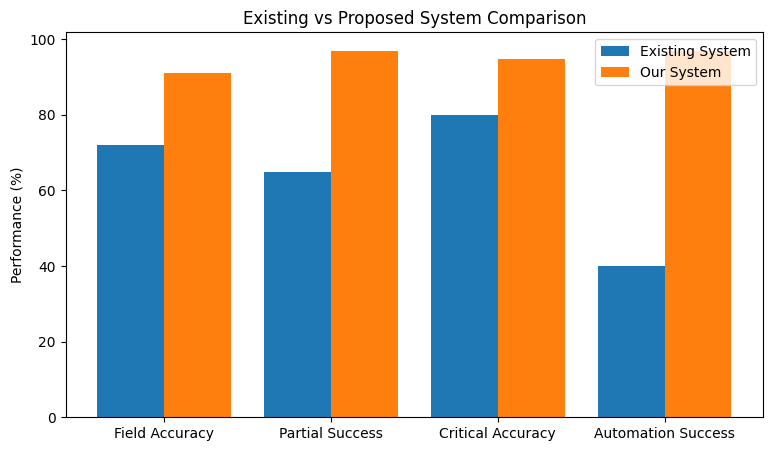

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    "Field Accuracy",
    "Partial Success",
    "Critical Accuracy",
    "Automation Success"
]

existing = [72, 65, 80, 40]

proposed = [91.2, 97, 94.67, 97]

x = range(len(metrics))

plt.figure(figsize=(9,5))

plt.bar(
    [i - 0.2 for i in x],
    existing,
    width=0.4,
    label="Existing System"
)

plt.bar(
    [i + 0.2 for i in x],
    proposed,
    width=0.4,
    label="Our System"
)

plt.xticks(x, metrics)

plt.ylabel("Performance (%)")

plt.title("Existing vs Proposed System Comparison")

plt.legend()

plt.savefig("graph1_comparison.png")

plt.show()

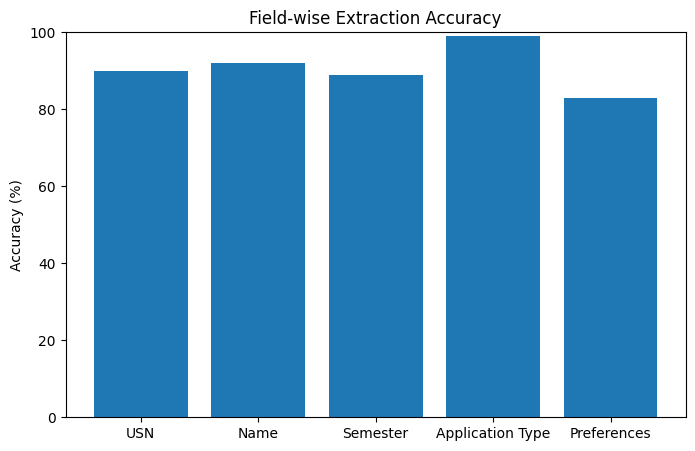

In [ ]:
import matplotlib.pyplot as plt

fields = [
    "USN",
    "Name",
    "Semester",
    "Application Type",
    "Preferences"
]

accuracy = [90, 92, 89, 99, 83]

plt.figure(figsize=(8,5))

plt.bar(fields, accuracy)

plt.ylim(0, 100)

plt.ylabel("Accuracy (%)")

plt.title("Field-wise Extraction Accuracy")

plt.savefig("graph2_field_accuracy.png")

plt.show()

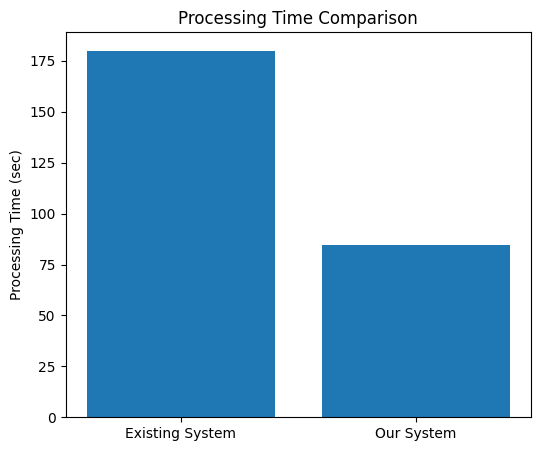

In [ ]:
import matplotlib.pyplot as plt

systems = [
    "Existing System",
    "Our System"
]

time_taken = [180, 84.59]

plt.figure(figsize=(6,5))

plt.bar(systems, time_taken)

plt.ylabel("Processing Time (sec)")

plt.title("Processing Time Comparison")

plt.savefig("graph3_processing_time.png")

plt.show()